Лабораторная работа №2
Классификация, оценка точности классификации

Для набора данных,  выбранного в первой лабораторной работе, необходимо провести сравнение результатов работы классификаторов из двух групп на выбор:
1. регрессия (линейная, нелинейная, логистическая, метод опорных векторов), k-ближайших соседей, деревья принятия решений (деревья, случайный лес) (один из методов на выбор);
2. методы с использованием стекинга, блендинга или бустинга (один из методов на выбор).
Для каждого метода необходимо построить матрицу ошибок и рассчитать одну из следующих метрик:
1. f-мера,
2. ROC AUC,
3. accuracy.

При обучении классификатора необходимо использовать кроссвалидацию.
Необходимо визуализировать изменение точности работы метода на разных шагах кроссвалидации. 
Необходимо показать как меняется точность классификации при изменении гиперпараметров.

Критерии оценивания:    
1. преобразование и очистка входных параметров (1 очко);
2. применение базовых методов классификации (2 очка);
3. применение продвинутых методов классификации (2 очка);
4. оценка точности (2 очка);
5. подбор гиперпараметров (2 очка);
6. использование кроссвалидации (1 очко).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score

## Читаем БД

In [2]:
df = pd.read_csv('../data/adult11.csv')

for column in df.columns:
    unique_vals = df[column].unique().tolist()
    print(f"Столбец '{column}': {unique_vals}")
    
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'salary']

Столбец 'age': [25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 36, 26, 58, 48, 43, 20, 37, 40, 72, 45, 22, 23, 54, 32, 46, 56, 17, 39, 52, 21, 42, 33, 30, 47, 41, 19, 69, 50, 31, 59, 49, 51, 27, 57, 61, 64, 79, 73, 53, 77, 80, 62, 35, 68, 66, 75, 60, 67, 71, 70, 90, 81, 74, 78, 82, 83, 85, 76, 84, 89, 88, 87, 86]
Столбец 'workclass': ['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
Столбец 'fnlwgt': [226802, 89814, 336951, 160323, 103497, 198693, 227026, 104626, 369667, 104996, 184454, 212465, 82091, 299831, 279724, 346189, 444554, 128354, 60548, 85019, 107914, 238588, 132015, 220931, 205947, 432824, 236427, 134446, 99516, 109282, 106444, 186651, 188274, 258120, 43311, 191846, 403681, 248446, 269430, 257509, 136384, 120277, 465326, 103634, 138371, 242832, 290208, 186272, 201062, 131916, 54440, 280215, 214399, 54164, 219446, 110677, 145985, 382078, 170721, 269705, 101135, 118429, 31208, 281384, 171807, 109912, 4453

## Чистим

In [3]:
df_clean = df.replace(['', '?'], np.nan).copy()

imputer = SimpleImputer(strategy='most_frequent')
df_clean['workclass'] = pd.Series(imputer.fit_transform(df[['workclass']]).ravel())
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

## Стандартизация

In [4]:
df_transformed = df_clean.copy()

for col in numeric_features:
    df_transformed[col] = pd.to_numeric(df_transformed[col], errors='coerce')

means = df_transformed[numeric_features].mean(axis=0)
stds = df_transformed[numeric_features].std(axis=0)
df_transformed[numeric_features] = (df_transformed[numeric_features] - means) / stds

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_transformed[col] = le.fit_transform(df_transformed[col].astype(str))
    label_encoders[col] = le

print("\nПосле стандартизации (M=0, D=1):")
print(df_transformed[numeric_features].round(3))


После стандартизации (M=0, D=1):
         age  fnlwgt  education-num  capital-gain  capital-loss  \
0     -0.995   0.352         -1.197        -0.145        -0.217   
1     -0.047  -0.946         -0.419        -0.145        -0.217   
2     -0.776   1.395          0.748        -0.145        -0.217   
3      0.391  -0.278         -0.030         0.887        -0.217   
4     -1.506  -0.816         -0.030        -0.145        -0.217   
...      ...     ...            ...           ...           ...   
48837 -0.849   0.640          0.748        -0.145        -0.217   
48838  0.099  -0.334         -0.419        -0.145        -0.217   
48839  1.412  -0.358         -0.419        -0.145        -0.217   
48840 -1.214   0.112         -0.419        -0.145        -0.217   
48841  0.974   0.930         -0.419         1.871        -0.217   

       hours-per-week  
0              -0.034  
1               0.773  
2              -0.034  
3              -0.034  
4              -0.841  
...              

## Выборка

In [5]:
X = df_transformed.drop('salary', axis=1)
y = df_transformed['salary']

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Размер X: (48842, 14)
Размер y: (48842,)


## Логистическая регрессия

In [6]:
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# ROC AUC (нужны вероятности, а не метки)
y_proba = lr.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.8558


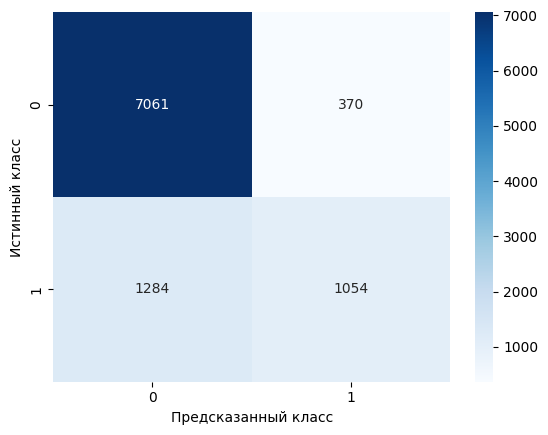

In [7]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# Кросс-валидация логистической регрессии

In [8]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_auc = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    lr = LogisticRegression(random_state=42, max_iter=2000)
    lr.fit(X_tr, y_tr)
    
    y_proba = lr.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_proba)
    
    fold_auc.append(auc)
    print(f"Фолд {fold+1}: ROC AUC = {auc:.4f}")

print(f"\nСреднее ROC AUC: {np.mean(fold_auc):.4f} (+/- {np.std(fold_auc):.4f})")

Фолд 1: ROC AUC = 0.8498
Фолд 2: ROC AUC = 0.8624
Фолд 3: ROC AUC = 0.8546
Фолд 4: ROC AUC = 0.8467
Фолд 5: ROC AUC = 0.8463

Среднее ROC AUC: 0.8520 (+/- 0.0060)


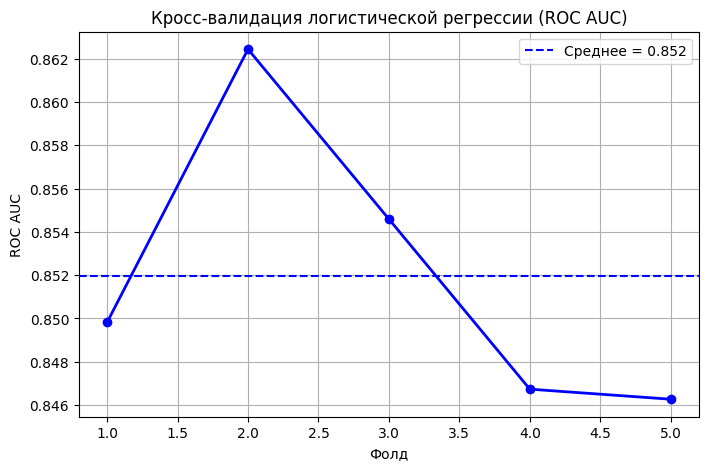

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), fold_auc, marker='o', color='blue', linewidth=2)
plt.axhline(np.mean(fold_auc), color='blue', linestyle='--', label=f'Среднее = {np.mean(fold_auc):.3f}')
plt.xlabel('Фолд')
plt.ylabel('ROC AUC')
plt.title('Кросс-валидация логистической регрессии (ROC AUC)')
plt.legend()
plt.grid()
plt.show()

## Гиперпараметры логистической регрессии

In [10]:
# Список значений гиперпараметра для перебора
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
mean_auc = []  # средний ROC AUC по фолдам
std_auc = []   # стандартное отклонение

# Настройки кросс-валидации
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for C in C_values:
    fold_scores = []
    for train_idx, val_idx in kfold.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        lr = LogisticRegression(C=C, random_state=42, max_iter=2000)
        lr.fit(X_tr, y_tr)
        y_proba = lr.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_proba)
        fold_scores.append(auc)
    
    mean_auc.append(np.mean(fold_scores))
    std_auc.append(np.std(fold_scores))
    print(f"C={C}: mean ROC AUC = {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

C=0.001: mean ROC AUC = 0.8427 (+/- 0.0067)
C=0.01: mean ROC AUC = 0.8511 (+/- 0.0063)
C=0.1: mean ROC AUC = 0.8520 (+/- 0.0061)
C=1: mean ROC AUC = 0.8520 (+/- 0.0060)
C=10: mean ROC AUC = 0.8520 (+/- 0.0060)
C=100: mean ROC AUC = 0.8520 (+/- 0.0060)
C=1000: mean ROC AUC = 0.8520 (+/- 0.0060)


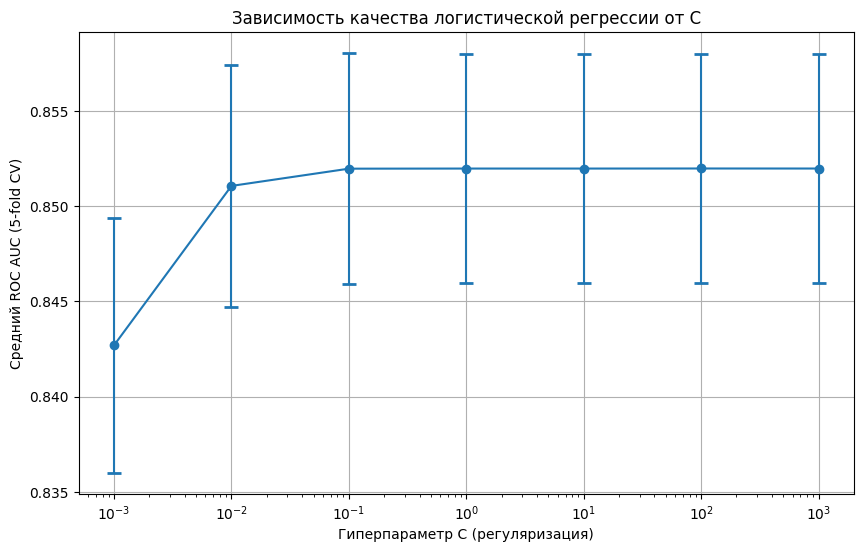

In [11]:
plt.figure(figsize=(10, 6))
plt.errorbar(C_values, mean_auc, yerr=std_auc, fmt='o-', capsize=5, capthick=2)
plt.xscale('log')
plt.xlabel('Гиперпараметр C (регуляризация)')
plt.ylabel('Средний ROC AUC (5-fold CV)')
plt.title('Зависимость качества логистической регрессии от C')
plt.grid(True)
plt.show()

## Бустинг

In [12]:
# Дисбаланс: ratio = число_0 / число_1
ratio = (y_train == 0).sum() / (y_train == 1).sum()  # ~3.18

model = xgb.XGBClassifier(
    scale_pos_weight=ratio,    # балансировка весов
    eval_metric='auc',         # метрика для ранней остановки
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# Обучение с ранней остановкой (предотвращает переобучение)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Предсказания
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))

ROC AUC: 0.9290767907635906


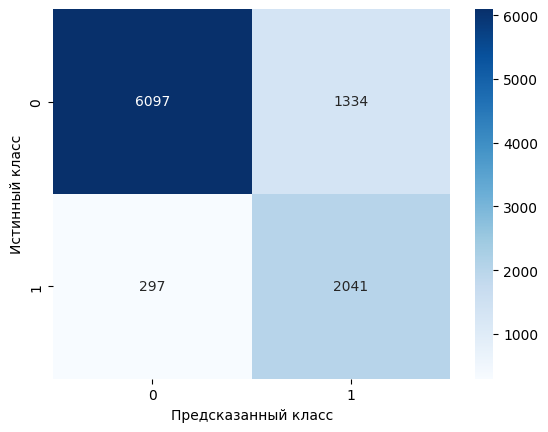

In [13]:
cm_xgb = confusion_matrix(y_test, y_pred)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

## Кросс-валидация бустинга

In [14]:
# Дисбаланс (рассчитывается один раз на всех обучающих данных)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Параметры модели
base_params = {
    'scale_pos_weight': ratio,
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'random_state': 42,
    'n_estimators': 1000,
    'early_stopping_rounds': 20
}

# Настройки кросс-валидации
n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_auc = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = xgb.XGBClassifier(**base_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    y_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_proba)
    
    fold_auc.append(auc)
    print(f"Фолд {fold+1}: ROC AUC = {auc:.4f}")

Фолд 1: ROC AUC = 0.9305
Фолд 2: ROC AUC = 0.9312
Фолд 3: ROC AUC = 0.9281
Фолд 4: ROC AUC = 0.9274
Фолд 5: ROC AUC = 0.9231


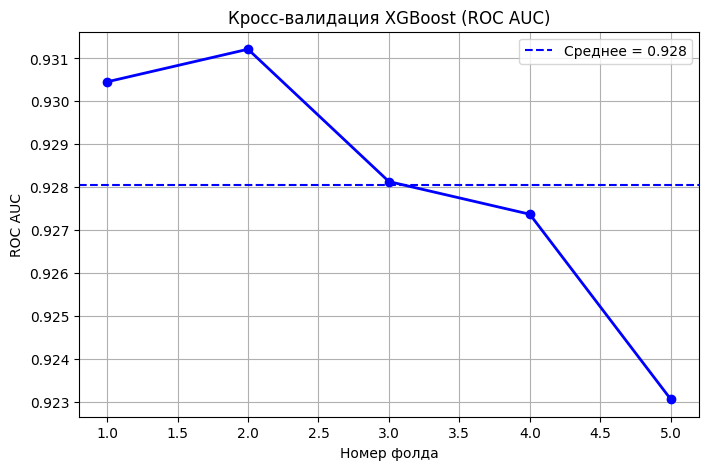

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_splits+1), fold_auc, marker='o', color='blue', linewidth=2)
plt.axhline(np.mean(fold_auc), color='blue', linestyle='--', label=f'Среднее = {np.mean(fold_auc):.3f}')
plt.xlabel('Номер фолда')
plt.ylabel('ROC AUC')
plt.title('Кросс-валидация XGBoost (ROC AUC)')
plt.legend()
plt.grid(True)
plt.show()

## Гиперпараметры для бустинга

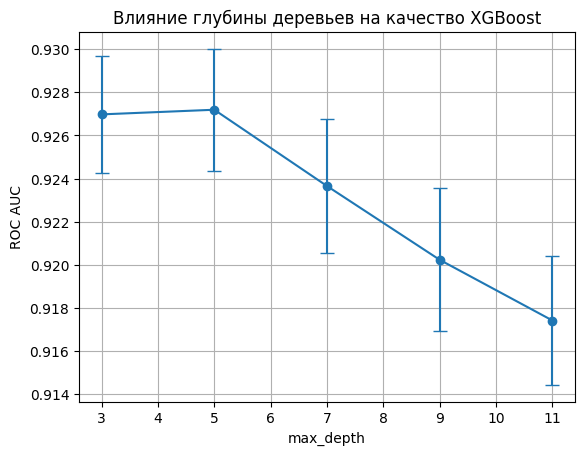

In [16]:
depth_values = [3, 5, 7, 9, 11]
mean_auc = []
std_auc = []

for depth in depth_values:
    fold_scores = []
    for train_idx, val_idx in kfold.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(max_depth=depth, random_state=42, eval_metric='auc', scale_pos_weight=3.18)
        model.fit(X_tr, y_tr)
        y_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_proba)
        fold_scores.append(auc)
    
    mean_auc.append(np.mean(fold_scores))
    std_auc.append(np.std(fold_scores))

plt.errorbar(depth_values, mean_auc, yerr=std_auc, fmt='o-', capsize=5)
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Влияние глубины деревьев на качество XGBoost')
plt.grid()
plt.show()